# Reference Problems – Input & Solution Graphs

Visualizations for all 5 examples from `PROBLEM.md`.

**Legend (tensor nodes):**
- 🟢 Green = graph input  |  🟡 Yellow = graph output  |  🔵 Blue = intermediate
- **★** (bold border) = tensor retained in fast memory between subgraphs
- Op boxes are color-coded and clustered by subgraph assignment


In [4]:
!pip install graphviz

In [5]:
import json, glob, os
import graphviz
from IPython.display import display


def draw_graph(data, title="Input Graph"):
    """Draw the input DAG from problem JSON."""
    dot = graphviz.Digraph(comment=title, format='svg')
    dot.attr(rankdir='LR', label=title, fontsize='14')
    dot.attr('node', fontsize='10')
    widths, heights = data['widths'], data['heights']
    ins, outs = data['inputs'], data['outputs']
    costs, types = data['base_costs'], data['op_types']
    produced = {t for o in outs for t in o}
    consumed = {t for i in ins for t in i}
    for i in range(len(widths)):
        color = ('lightgreen' if i not in produced
                 else 'lightyellow' if i not in consumed
                 else 'lightblue')
        dot.node(f'T{i}', f"T[{i}]\n{widths[i]}x{heights[i]}",
                 shape='ellipse', style='filled', fillcolor=color)
    for i in range(len(costs)):
        dot.node(f'Op{i}', f"Op[{i}]\n{types[i]}\ncost={costs[i]}",
                 shape='box', style='filled', fillcolor='lightsalmon')
        for t in ins[i]:  dot.edge(f'T{t}', f'Op{i}')
        for t in outs[i]: dot.edge(f'Op{i}', f'T{t}')
    return dot


SG_COLORS = ['#FF8888', '#88CC88', '#8888EE', '#FFCC44', '#FF88CC', '#44CCFF']


def draw_schedule(data, schedule, title="Schedule"):
    """Draw the DAG with ops color-coded and clustered by subgraph."""
    dot = graphviz.Digraph(comment=title, format='svg')
    dot.attr(rankdir='LR', label=title, fontsize='14', compound='true')
    dot.attr('node', fontsize='10')
    widths, heights = data['widths'], data['heights']
    ins, outs = data['inputs'], data['outputs']
    costs, types = data['base_costs'], data['op_types']
    sgs   = schedule['subgraphs']
    grans = schedule['granularities']
    retain = schedule.get('tensors_to_retain', [[] for _ in sgs])
    trav   = schedule.get('traversal_orders',  [None] * len(sgs))
    lats   = schedule.get('subgraph_latencies', [None] * len(sgs))
    retained = {t for r in retain for t in r}
    produced = {t for o in outs for t in o}
    consumed = {t for i in ins for t in i}
    for i in range(len(widths)):
        color = ('lightgreen' if i not in produced
                 else 'lightyellow' if i not in consumed
                 else 'lightblue')
        suffix = ' *' if i in retained else ''
        pw     = '3'  if i in retained else '1'
        dot.node(f'T{i}', f"T[{i}]{suffix}\n{widths[i]}x{heights[i]}",
                 shape='ellipse', style='filled', fillcolor=color, penwidth=pw)
    for sg_i, ops in enumerate(sgs):
        g   = grans[sg_i]
        lat = lats[sg_i]
        t   = trav[sg_i] if trav and trav[sg_i] is not None else 'raster'
        lat_s  = f"{lat:,.1f}" if lat is not None else "N/A"
        clabel = f"SG[{sg_i}]  [{g[0]}x{g[1]}, k={g[2]}]\nlatency={lat_s}  order={t}"
        col = SG_COLORS[sg_i % len(SG_COLORS)]
        with dot.subgraph(name=f'cluster_{sg_i}') as c:
            c.attr(label=clabel, style='rounded,filled',
                   fillcolor=col, color='#555555', penwidth='2', fontsize='9')
            for op in ops:
                c.node(f'Op{op}', f"Op[{op}]\n{types[op]}\ncost={costs[op]}",
                       shape='box', style='filled', fillcolor=col)
    for i in range(len(costs)):
        for t in ins[i]:  dot.edge(f'T{t}', f'Op{i}')
        for t in outs[i]: dot.edge(f'Op{i}', f'T{t}')
    return dot


---
## Example 1: Baseline

Chain of 2 Pointwise ops on **128×128** tensors.
`fast_memory_capacity=35000`, `native_granularity=[128,128]`

Three strategies explore the trade-off between spilling and fusion.


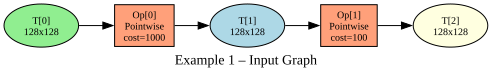

In [6]:
ex1 = {
    "widths":  [128, 128, 128],
    "heights": [128, 128, 128],
    "inputs":  [[0], [1]],
    "outputs": [[1], [2]],
    "base_costs": [1000, 100],
    "op_types": ["Pointwise", "Pointwise"],
    "fast_memory_capacity": 35000,
    "slow_memory_bandwidth": 10,
    "native_granularity": [128, 128],
}
display(draw_graph(ex1, "Example 1 – Input Graph"))


### Strategy A: Always Spill — Total Latency = **6,553.6** (memory bound)

Each op runs separately. T[1] is evicted after SG[0] then reloaded for SG[1].


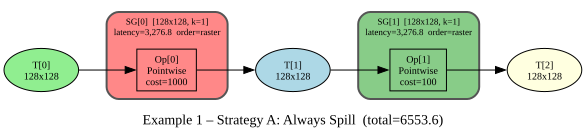

In [7]:
ex1_a = {
    "subgraphs":           [[0], [1]],
    "granularities":       [[128, 128, 1], [128, 128, 1]],
    "tensors_to_retain":   [[], []],
    "traversal_orders":    [None, None],
    "subgraph_latencies":  [3276.8, 3276.8],
}
display(draw_schedule(ex1, ex1_a, "Example 1 – Strategy A: Always Spill  (total=6553.6)"))


### Strategy B: Mega-Group 128×128 — Total Latency = **3,276.8** ← 2× faster than A

Both ops fused; T[1] becomes ephemeral (zero memory cost, zero latency).


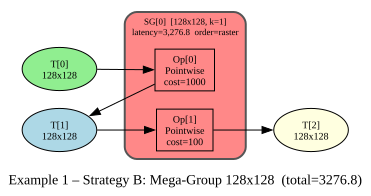

In [8]:
ex1_b = {
    "subgraphs":           [[0, 1]],
    "granularities":       [[128, 128, 1]],
    "tensors_to_retain":   [[]],
    "traversal_orders":    [None],
    "subgraph_latencies":  [3276.8],
}
display(draw_schedule(ex1, ex1_b, "Example 1 – Strategy B: Mega-Group 128x128  (total=3276.8)"))


### Strategy C: Mega-Group 64×64 — Total Latency = **4,400.0** (1.5× faster than A)

Finer granularity → 4 passes, each compute-bound (cost=1100 > mem=819.2).


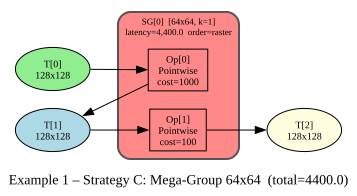

In [9]:
ex1_c = {
    "subgraphs":           [[0, 1]],
    "granularities":       [[64, 64, 1]],
    "tensors_to_retain":   [[]],
    "traversal_orders":    [None],
    "subgraph_latencies":  [4400.0],
}
display(draw_schedule(ex1, ex1_c, "Example 1 – Strategy C: Mega-Group 64x64  (total=4400.0)"))


---
## Example 2: Fast Memory Capacity

Same 2-op chain but tensors are **256×256**.
`fast_memory_capacity=25000` — too small for a full 256×256 tensor (65536 elements).
Granularity is forced to ≤ 128×128, so both strategies need 4 passes.


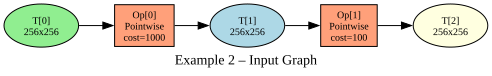

In [10]:
ex2 = {
    "widths":  [256, 256, 256],
    "heights": [256, 256, 256],
    "inputs":  [[0], [1]],
    "outputs": [[1], [2]],
    "base_costs": [1000, 100],
    "op_types": ["Pointwise", "Pointwise"],
    "fast_memory_capacity": 25000,
    "slow_memory_bandwidth": 10,
    "native_granularity": [128, 128],
}
display(draw_graph(ex2, "Example 2 – Input Graph"))


### Strategy A: Always Spill — Total Latency = **26,214.4** (memory bound)

4 passes each subgraph; T[1] evicted after SG[0] and reloaded for SG[1].


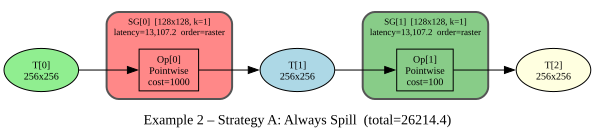

In [11]:
ex2_a = {
    "subgraphs":           [[0], [1]],
    "granularities":       [[128, 128, 1], [128, 128, 1]],
    "tensors_to_retain":   [[], []],
    "traversal_orders":    [None, None],
    "subgraph_latencies":  [13107.2, 13107.2],
}
display(draw_schedule(ex2, ex2_a, "Example 2 – Strategy A: Always Spill  (total=26214.4)"))


### Strategy B: Mega-Group 128×128 — Total Latency = **13,107.2** ← 2× faster than A

Both ops fused; T[1] ephemeral; 4 passes still needed but T[1] is never evicted/reloaded.


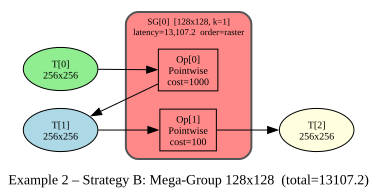

In [12]:
ex2_b = {
    "subgraphs":           [[0, 1]],
    "granularities":       [[128, 128, 1]],
    "tensors_to_retain":   [[]],
    "traversal_orders":    [None],
    "subgraph_latencies":  [13107.2],
}
display(draw_schedule(ex2, ex2_b, "Example 2 – Strategy B: Mega-Group 128x128  (total=13107.2)"))


---
## Example 3: Spilling vs. Recomputation (Diamond Graph)

T[1] is consumed by **both** Op[1] and Op[2] (skip connection).
`fast_memory_capacity=50000`.


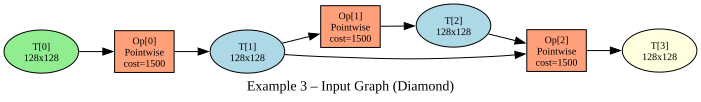

In [13]:
ex3 = {
    "widths":  [128, 128, 128, 128],
    "heights": [128, 128, 128, 128],
    "inputs":  [[0], [1], [1, 2]],
    "outputs": [[1], [2], [3]],
    "base_costs": [1500, 1500, 1500],
    "op_types": ["Pointwise", "Pointwise", "Pointwise"],
    "fast_memory_capacity": 50000,
    "slow_memory_bandwidth": 10,
    "native_granularity": [128, 128],
}
display(draw_graph(ex3, "Example 3 – Input Graph (Diamond)"))


### Strategy A: Spilling (Cache Approach) — Total Latency = **11,468.8**

3 separate subgraphs. T[1] evicted after SG[0], reloaded for both SG[1] and SG[2].


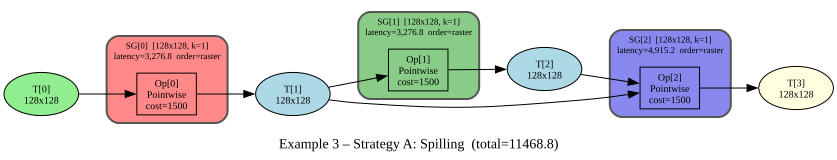

In [14]:
ex3_a = {
    "subgraphs":           [[0], [1], [2]],
    "granularities":       [[128, 128, 1], [128, 128, 1], [128, 128, 1]],
    "tensors_to_retain":   [[], [], []],
    "traversal_orders":    [None, None, None],
    "subgraph_latencies":  [3276.8, 3276.8, 4915.2],
}
display(draw_schedule(ex3, ex3_a, "Example 3 – Strategy A: Spilling  (total=11468.8)"))


### Strategy B: Recomputation (Flash Approach) — Total Latency = **6,276.8** (45% faster than A)

Op[0] is executed **twice** to avoid storing T[1]. T[2] kept resident.


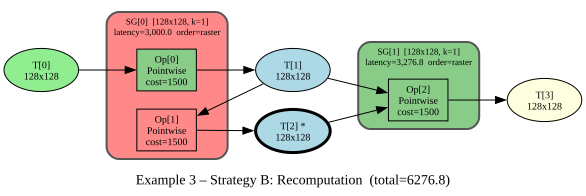

In [15]:
ex3_b = {
    "subgraphs":           [[0, 1], [0, 2]],
    "granularities":       [[128, 128, 1], [128, 128, 1]],
    "tensors_to_retain":   [[2], []],
    "traversal_orders":    [None, None],
    "subgraph_latencies":  [3000.0, 3276.8],
}
display(draw_schedule(ex3, ex3_b, "Example 3 – Strategy B: Recomputation  (total=6276.8)"))


### Strategy C: Selective Residency (Hybrid) — Total Latency = **4,638.4** ← 60% faster than A ✓

T[1] kept resident in fast memory (*). Op[1] and Op[2] fused in SG[1].


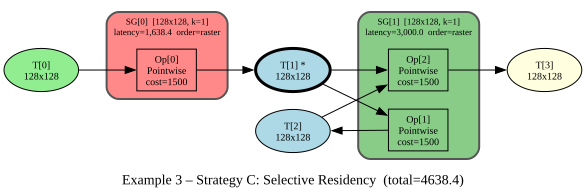

In [16]:
ex3_c = {
    "subgraphs":           [[0], [1, 2]],
    "granularities":       [[128, 128, 1], [128, 128, 1]],
    "tensors_to_retain":   [[1], []],
    "traversal_orders":    [None, None],
    "subgraph_latencies":  [1638.4, 3000.0],
}
display(draw_schedule(ex3, ex3_c, "Example 3 – Strategy C: Selective Residency  (total=4638.4)"))


---
## Example 4: Revisit (MatMul Traversal Order)

Single MatMul on **128×128** tensors. `fast_memory_capacity=25000`.
All 3 tensors together = 3×16384 = 49152 > 25000 → must use 64×64 granularity (4 tiles).
Traversal order determines how many input strips must be reloaded.


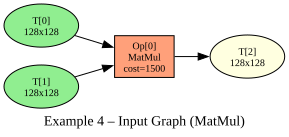

In [17]:
ex4 = {
    "widths":  [128, 128, 128],
    "heights": [128, 128, 128],
    "inputs":  [[0, 1]],
    "outputs": [[2]],
    "base_costs": [1500],
    "op_types": ["MatMul"],
    "fast_memory_capacity": 25000,
    "slow_memory_bandwidth": 10,
    "native_granularity": [128, 128],
}
display(draw_graph(ex4, "Example 4 – Input Graph (MatMul)"))


### Strategy A: Naive Tiling (Raster Order) — Total Latency = **8,192** (memory bound)

Default raster order: 0→1→2→3. Every tile reloads both input strips (no reuse).


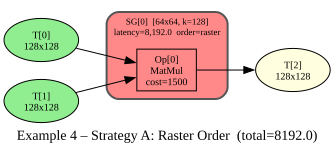

In [18]:
ex4_a = {
    "subgraphs":           [[0]],
    "granularities":       [[64, 64, 128]],
    "tensors_to_retain":   [[]],
    "traversal_orders":    [None],
    "subgraph_latencies":  [8192.0],
}
display(draw_schedule(ex4, ex4_a, "Example 4 – Strategy A: Raster Order  (total=8192.0)"))


### Strategy B: Zig-Zag Traversal — Total Latency = **6,548** ← 20% faster than A

Order 0→1→3→2: adjacent tiles share a loaded strip, saving one reload per step.

| Tile | Load        | Cost |
|------|-------------|------|
| 0    | row0 + col0 | 2048 (mem-bound) |
| 1    | reuse row0, load col1 | 1500 (compute-bound) |
| 3    | load row1, reuse col1 | 1500 (compute-bound) |
| 2    | reuse row1, load col0 | 1500 (compute-bound) |


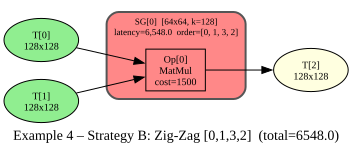

In [19]:
ex4_b = {
    "subgraphs":           [[0]],
    "granularities":       [[64, 64, 128]],
    "tensors_to_retain":   [[]],
    "traversal_orders":    [[0, 1, 3, 2]],
    "subgraph_latencies":  [6548.0],
}
display(draw_schedule(ex4, ex4_b, "Example 4 – Strategy B: Zig-Zag [0,1,3,2]  (total=6548.0)"))


---
## Example 5: Chained MatMul (Split-K)

Two chained MatMuls: `(T[0] @ T[1]) @ T[2]`.
`fast_memory_capacity=45000`.
Three full 128×128 tensors = 3×16384 = **49152 > 45000** — grouping with k=128 causes OOM.


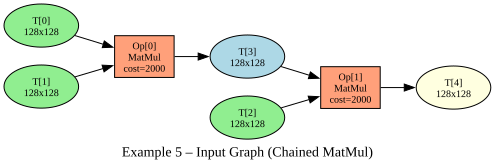

In [20]:
ex5 = {
    "widths":  [128, 128, 128, 128, 128],
    "heights": [128, 128, 128, 128, 128],
    "inputs":  [[0, 1], [3, 2]],
    "outputs": [[3], [4]],
    "base_costs": [2000, 2000],
    "op_types": ["MatMul", "MatMul"],
    "fast_memory_capacity": 45000,
    "slow_memory_bandwidth": 10,
    "native_granularity": [128, 128],
}
display(draw_graph(ex5, "Example 5 – Input Graph (Chained MatMul)"))


### Strategy A: Materialization (k=128) — **OOM ❌**

Working set = T[0](16384) + T[1](16384) + T[3](16384) = **49,152 > 45,000**. Crashes!


In [21]:
print("Strategy A – k=128:")
print("  Working set = T[0](16384) + T[1](16384) + T[3](16384) = 49,152")
print("  fast_memory_capacity = 45,000")
print("  49,152 > 45,000  →  OUT OF MEMORY – cannot execute")


Strategy A – k=128:
  Working set = T[0](16384) + T[1](16384) + T[3](16384) = 49,152
  fast_memory_capacity = 45,000
  49,152 > 45,000  →  OUT OF MEMORY – cannot execute


### Strategy B: Split-K (k=32) — Total Latency = **6,915.2** ← Only valid strategy

k=32 → keep T[0](16384) + accumulator T[4](16384) resident; stream T[1] & T[2] in 32-col strips (4096 each).
Working set = 16384 + 16384 + 4096 + 4096 = **40,960 < 45,000** ✓

4 accumulation steps; first and last are memory-bound, middle two are compute-bound.


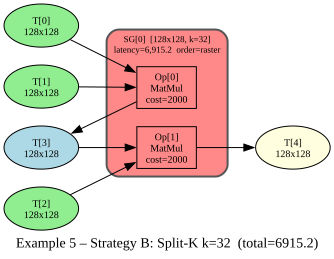

In [22]:
ex5_b = {
    "subgraphs":           [[0, 1]],
    "granularities":       [[128, 128, 32]],
    "tensors_to_retain":   [[]],
    "traversal_orders":    [None],
    "subgraph_latencies":  [6915.2],
}
display(draw_schedule(ex5, ex5_b, "Example 5 – Strategy B: Split-K k=32  (total=6915.2)"))


---
## Benchmark Graphs


In [23]:
benchmark_files = sorted(glob.glob('benchmarks/mlsys-2026-*.json'))
print(f"Found {len(benchmark_files)} benchmarks: {[os.path.basename(f) for f in benchmark_files]}")


Found 6 benchmarks: ['mlsys-2026-0.json', 'mlsys-2026-1.json', 'mlsys-2026-13.json', 'mlsys-2026-17.json', 'mlsys-2026-5.json', 'mlsys-2026-9.json']



mlsys-2026-0: 4 tensors, 3 ops


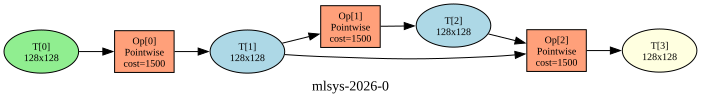


mlsys-2026-1: 9 tensors, 5 ops


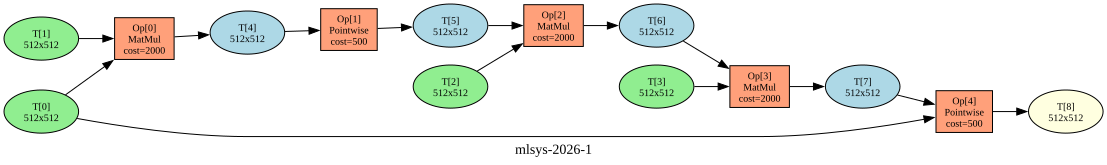


mlsys-2026-13: 100 tensors, 63 ops


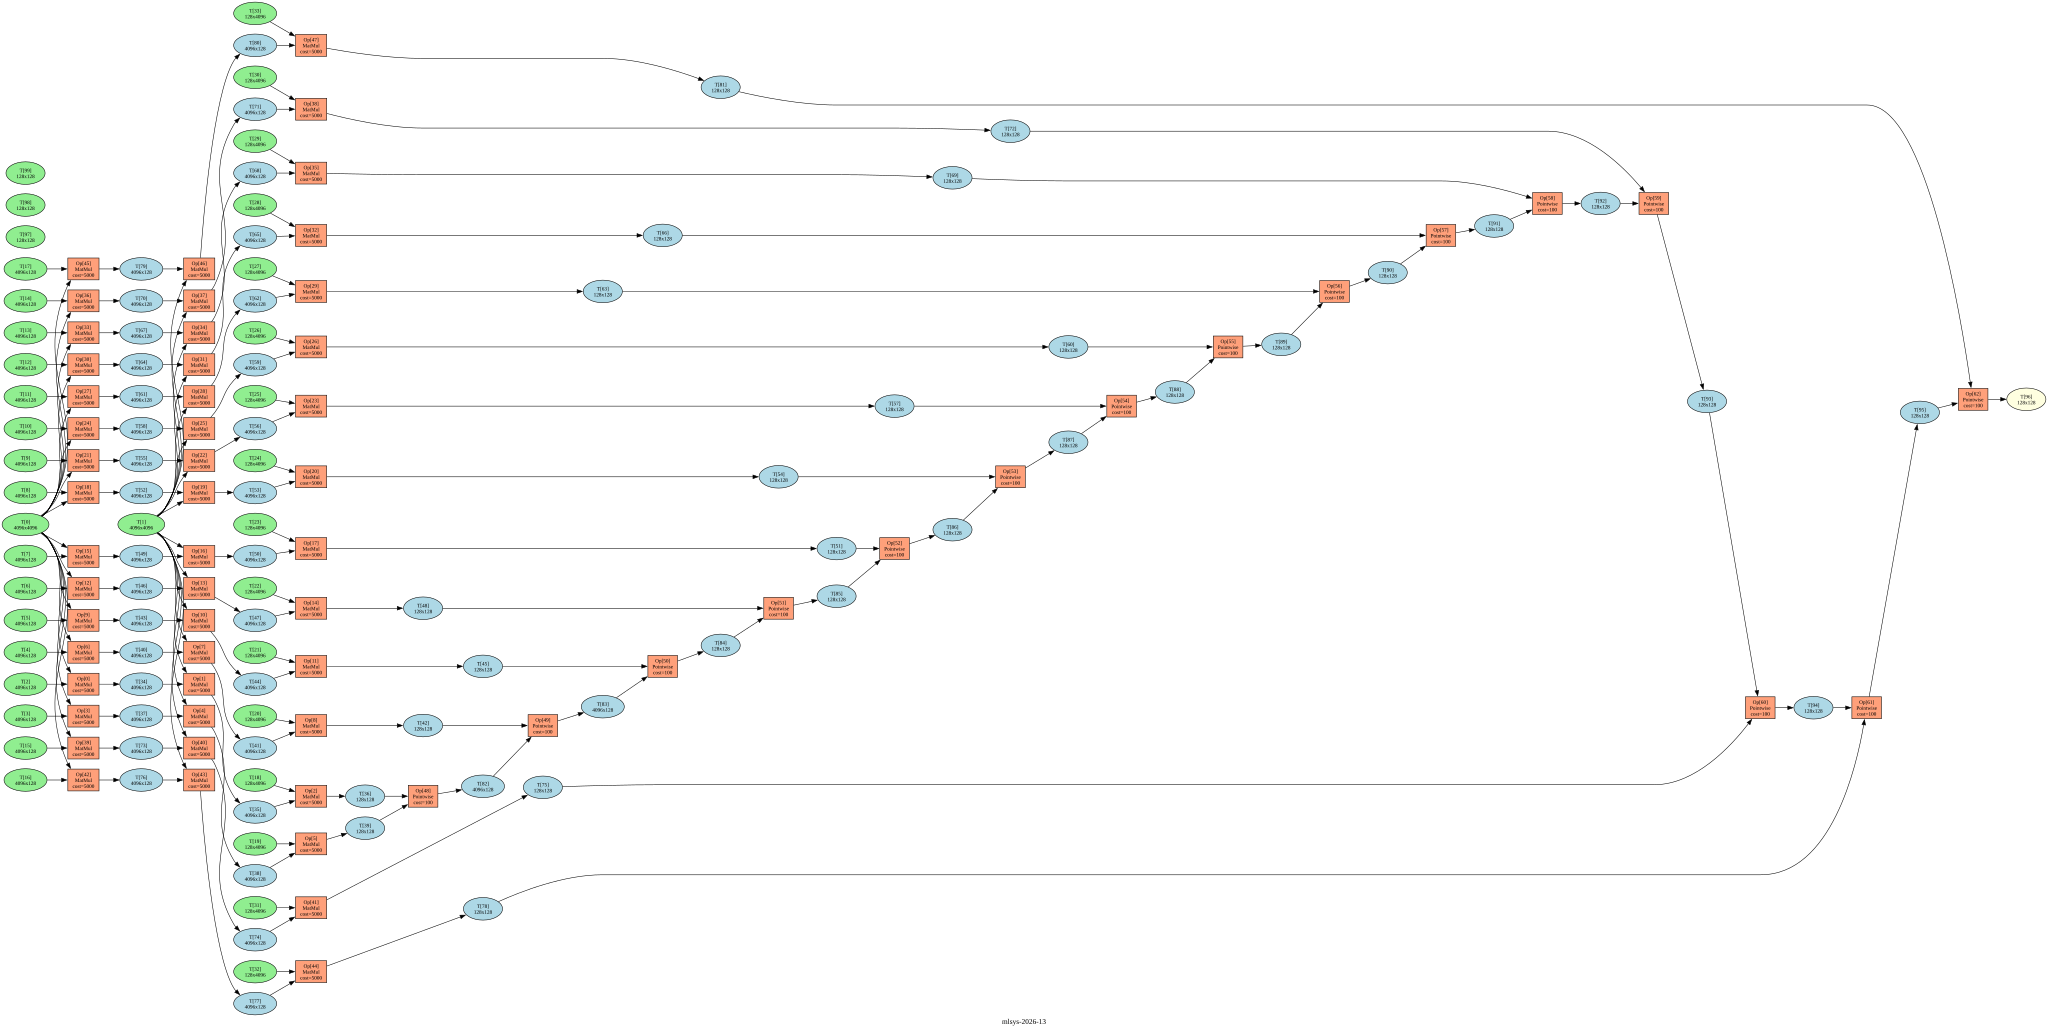


mlsys-2026-17: 160 tensors, 103 ops


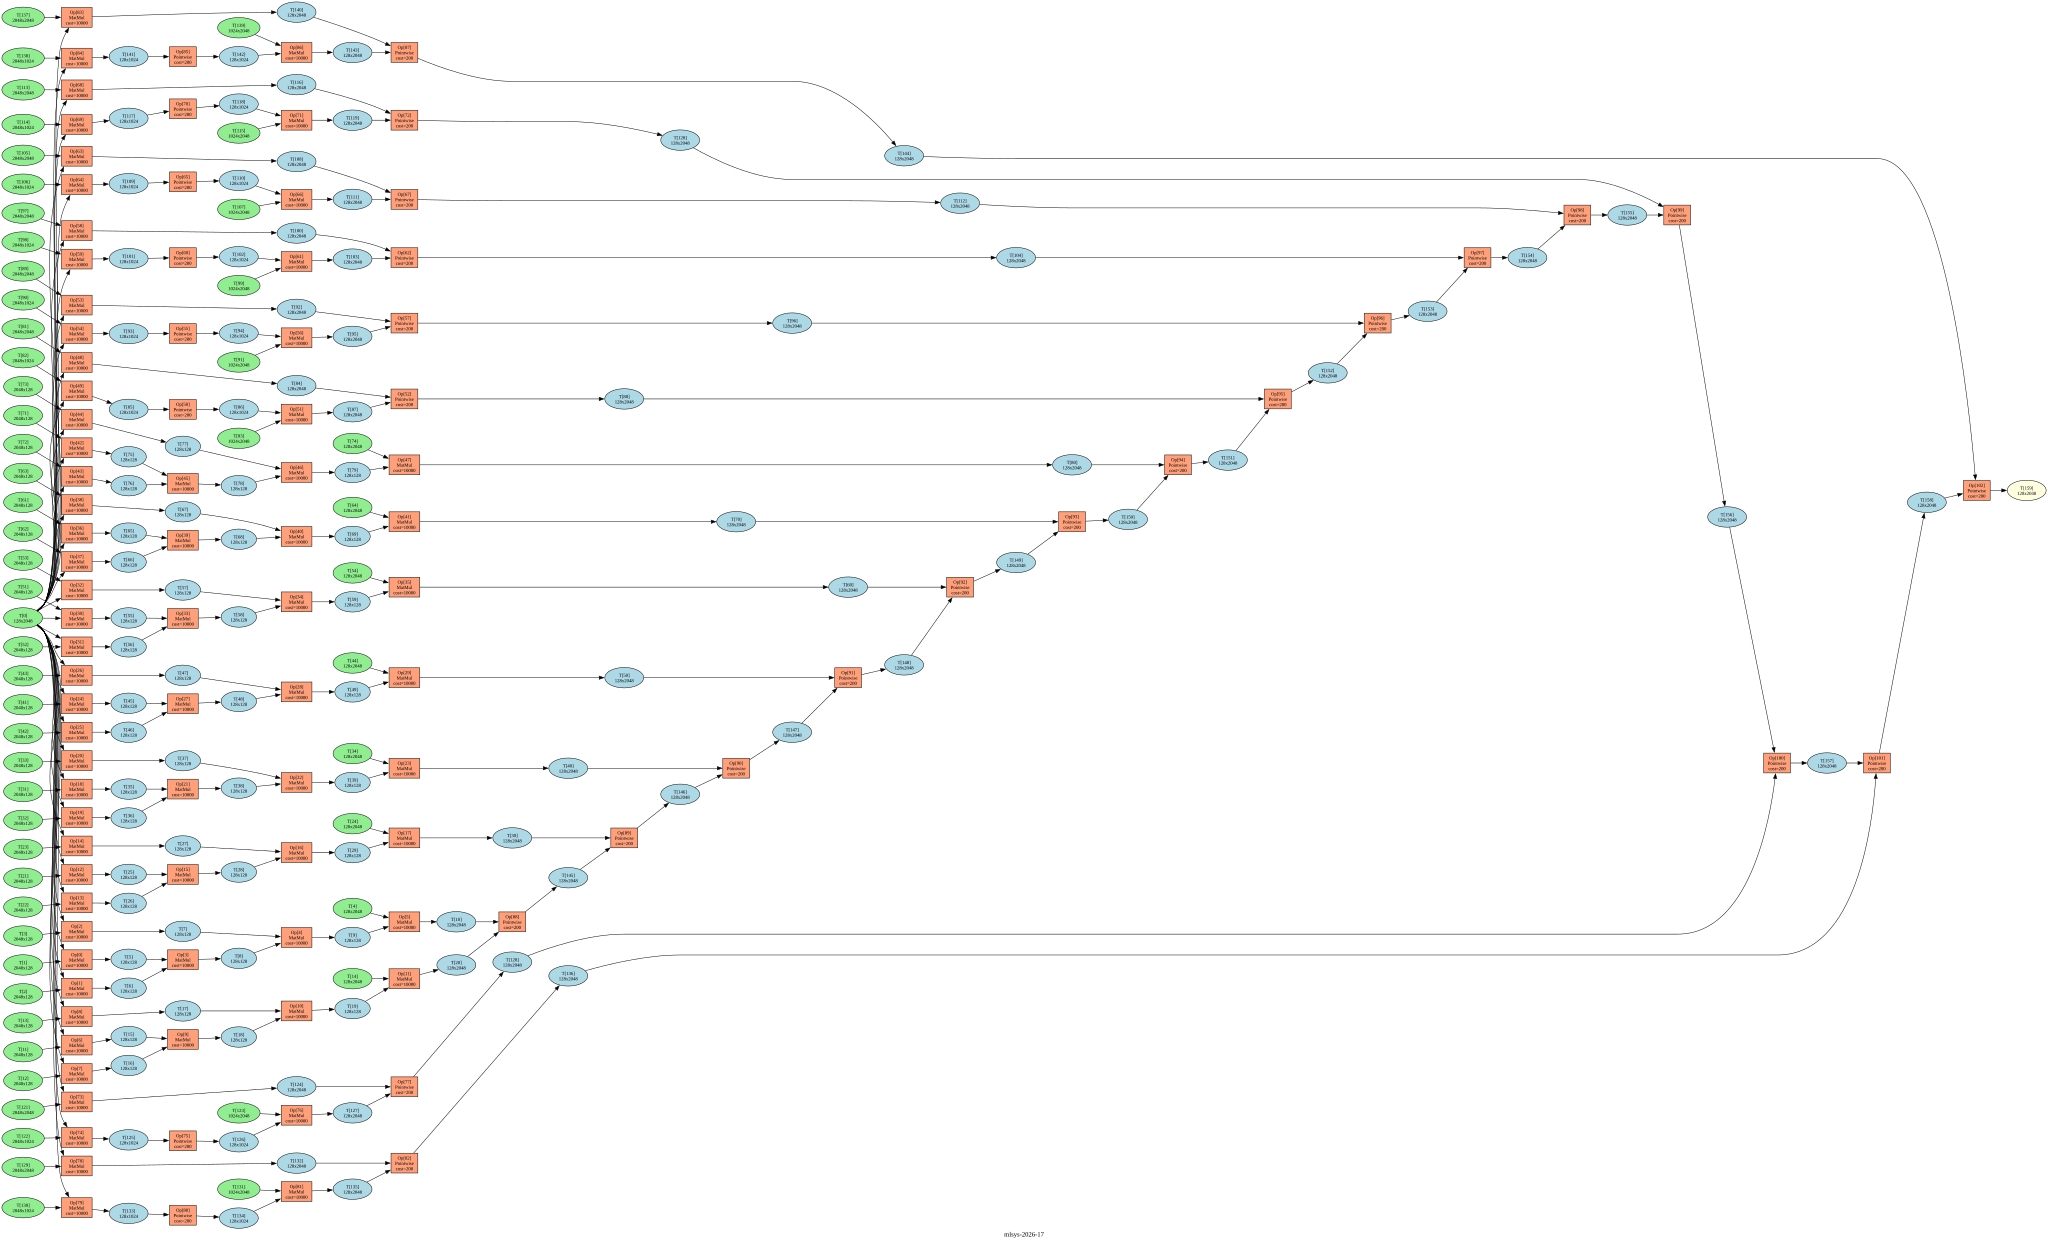


mlsys-2026-5: 29 tensors, 19 ops


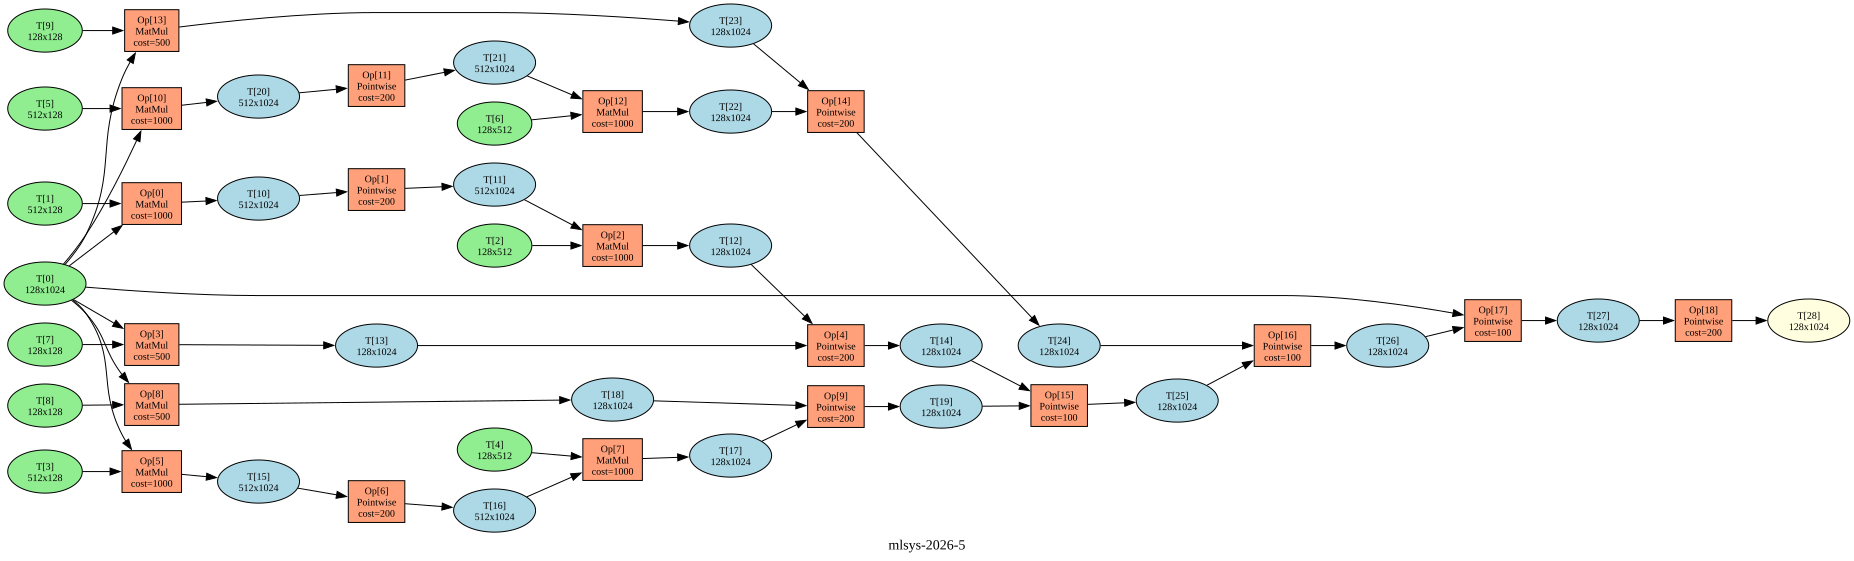


mlsys-2026-9: 49 tensors, 32 ops


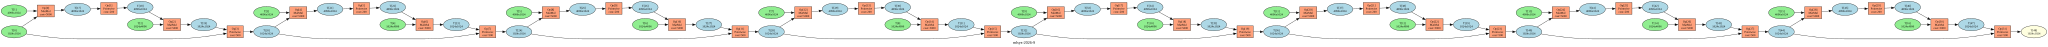

In [24]:
for fpath in benchmark_files:
    with open(fpath) as f:
        data = json.load(f)
    name = os.path.basename(fpath).replace('.json', '')
    n_tensors = len(data['widths'])
    n_ops = len(data['base_costs'])
    print(f"\n{name}: {n_tensors} tensors, {n_ops} ops")
    display(draw_graph(data, name))
